# Libraries & Paths

In [1]:
import random, os, json, warnings
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
import decoupler as dc

# Seed of use for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Wandb import
#import wandb
#wandb.login()  
# Use of wandb (Weights & Biases) to track model configurations, performance metrics, plots, and experiment comparisons in a reproducible way.

# Setting the path of input & output data 
data_dir   = Path('../data')   
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)
filtered_anndata = output_dir / "filtered_anndata.h5ad"


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print ("Loaded")

Loaded


# Loading AnnData

In [2]:
# Loading Annadata
adata = sc.read_h5ad(filtered_anndata)


# Reloading the anndata for re-checking its values and shape while also printing the expression value range of the samples in the expression matrix.
print(f"AnnData shape: {adata.shape}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"First 5 gene names: {adata.var_names[:5].tolist()}")
X_sample = adata.X[:100, :100]
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
print(f"Expression value range of samples: [{X_sample.min():.2f}, {X_sample.max():.2f}]")

AnnData shape: (16291, 10019)
obs columns: ['sample', 'patient_timepoint', 'response_label', 'therapy', 'timepoint', 'patient_id', 'response', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']
First 5 gene names: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'FUCA2']
Expression value range of samples: [0.00, 12.24]


---
# Per-cell Pathway Activity Score

In [3]:
# Loading PROGENy pathway-gene weight matrix where top = 500 (default) responsive genes per pathway are used.
progeny= dc.op.progeny(organism='human', top=500) # [9]
print(f"PROGENy dataset shape: {progeny.shape}")
print(f"Column info: {progeny.columns.tolist()}")
print(f"Total pathways: {progeny['source'].nunique()}")
print(f"Naming of Pathways: {sorted(progeny['source'].unique())}")

display(progeny.head(10))

PROGENy dataset shape: (6463, 4)
Column info: ['source', 'target', 'weight', 'padj']
Total pathways: 14
Naming of Pathways: ['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53']


,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
5,Androgen,SLC38A4,7.363805,1.253071e-39
6,Androgen,MTMR9,6.130646,2.534403e-38
7,Androgen,ZBTB16,10.614437,1.567152e-36
8,Androgen,KCNN2,9.473199,7.711872e-36
9,Androgen,OPRK1,-5.626074,1.114245e-35


## Overlap check PROGENy \ AnnData

In [4]:
progeny_genes = set(progeny["target"].unique())
adata_genes = set(adata.var_names.astype(str))
overlap_genes = progeny_genes & adata_genes

print(f"PROGENy: {len(progeny_genes):,}")
print(f"AnnData has {len(adata_genes):,} genes")
print(f"Overlap: {len(overlap_genes):,} genes ({len(overlap_genes)/len(progeny_genes)*100:.1f}% of PROGENy genes found)")
# Having >= 50% overlap is sufficient for reliable PROGENy scoring

PROGENy: 5,276
AnnData has 10,019 genes
Overlap: 3,120 genes (59.1% of PROGENy genes found)


**Comment:** Of the 10,019 genes remaining after filtering, 3,120 overlap with the PROGENy gene set, representing 59.1% of the PROGENy genes identified, which are used to calculate pathway activity scores.   

Those pathway scores will be added as additional features, possibly providing biological information about the activity of major signaling pathways that may not be directly captured from individual gene-expression values alone.

In [5]:
# Running decoupler MLM to compute per-cell PROGENy pathway activity scores
# tmin=5 default (minimum number of targers per source--> fewer targets removed) [10]
dc.mt.mlm(data=adata,net=progeny, tmin=5,raw=False,verbose=True) 

# Extracting pathway scores from adata.obsm
# Cells --> rows
# Pathways --> columns
pathway_scores = dc.pp.get_obsm(adata,key="score_mlm") #[11]

# Printing info regarding the final shape of the pathway score matrix of all  genes
# while displaying the form of the matrix - first 5 rows.
print(f"\nPathway score matrix shape: {pathway_scores.shape}")
display(pathway_scores.to_df().head())

2026-06-23 01:55:23 | [INFO] mlm - Running mlm
2026-06-23 01:55:23 | [INFO] Extracted omics mat with 16291 rows (observations) and 10019 columns (features)
2026-06-23 01:55:23 | [INFO] Network adjacency matrix has 3120 unique features and 14 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-06-23 01:55:24 | [INFO] mlm - fitting 14 multivariate models of 10019 observations with 10004 degrees of freedom
2026-06-23 01:55:46 | [INFO] mlm - done



Pathway score matrix shape: (16291, 14)


,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
cell_id,,,,,,,,,,,,,,
A10_P3_M11,-1.138683,1.228258,-0.251242,2.007235,-0.039780,-1.790931,0.874541,1.735108,0.199134,1.935240,-2.157990,0.456511,0.302499,1.887193
A11_P1_M11,1.377561,2.240259,0.489674,0.905588,1.468313,-1.253552,-0.483265,1.804137,3.090768,2.369037,-0.713861,-0.150261,-0.129433,1.378969
A11_P3_M11,-0.864960,3.157435,-0.955709,0.878419,8.415694,-3.492376,0.412602,1.947071,0.729380,1.533553,-1.410822,-2.035881,0.191990,-0.012283
A11_P4_M11,-0.670113,1.429251,-0.487390,2.136176,3.224336,-2.244000,0.212930,1.176530,-0.039328,1.269244,-3.217768,-0.154373,-0.905839,1.056354
A12_P3_M11,0.267677,1.136369,0.819472,0.448110,1.591588,-0.536369,4.153850,2.942982,1.109443,0.407819,-0.665201,-0.125597,-0.428076,1.532233


## QC for Pathway Scores

In [6]:
# Checking for missing values
pathway_qc = pathway_scores.to_df()
print("Missing values per pathway:")
print(pathway_qc.isna().sum())

# Checking pathway score variance
variances = pathway_qc.var().sort_values()
print("\nPathway variances:")
print(variances.round(4)) 
# All of them have reasonable variances larger than > 0.01

Missing values per pathway:
Androgen    0
EGFR        0
Estrogen    0
Hypoxia     0
JAK-STAT    0
MAPK        0
NFkB        0
PI3K        0
TGFb        0
TNFa        0
Trail       0
VEGF        0
WNT         0
p53         0
dtype: int64

Pathway variances:
Estrogen     0.7355
Androgen     0.7826
VEGF         0.7857
TGFb         0.8883
WNT          0.9120
Trail        1.1279
TNFa         1.1951
EGFR         1.2605
PI3K         1.3178
MAPK         1.3586
p53          1.9547
Hypoxia      2.1472
NFkB         2.2249
JAK-STAT    10.3467
dtype: float64


## Set of Visualizations for the Pathway Scores

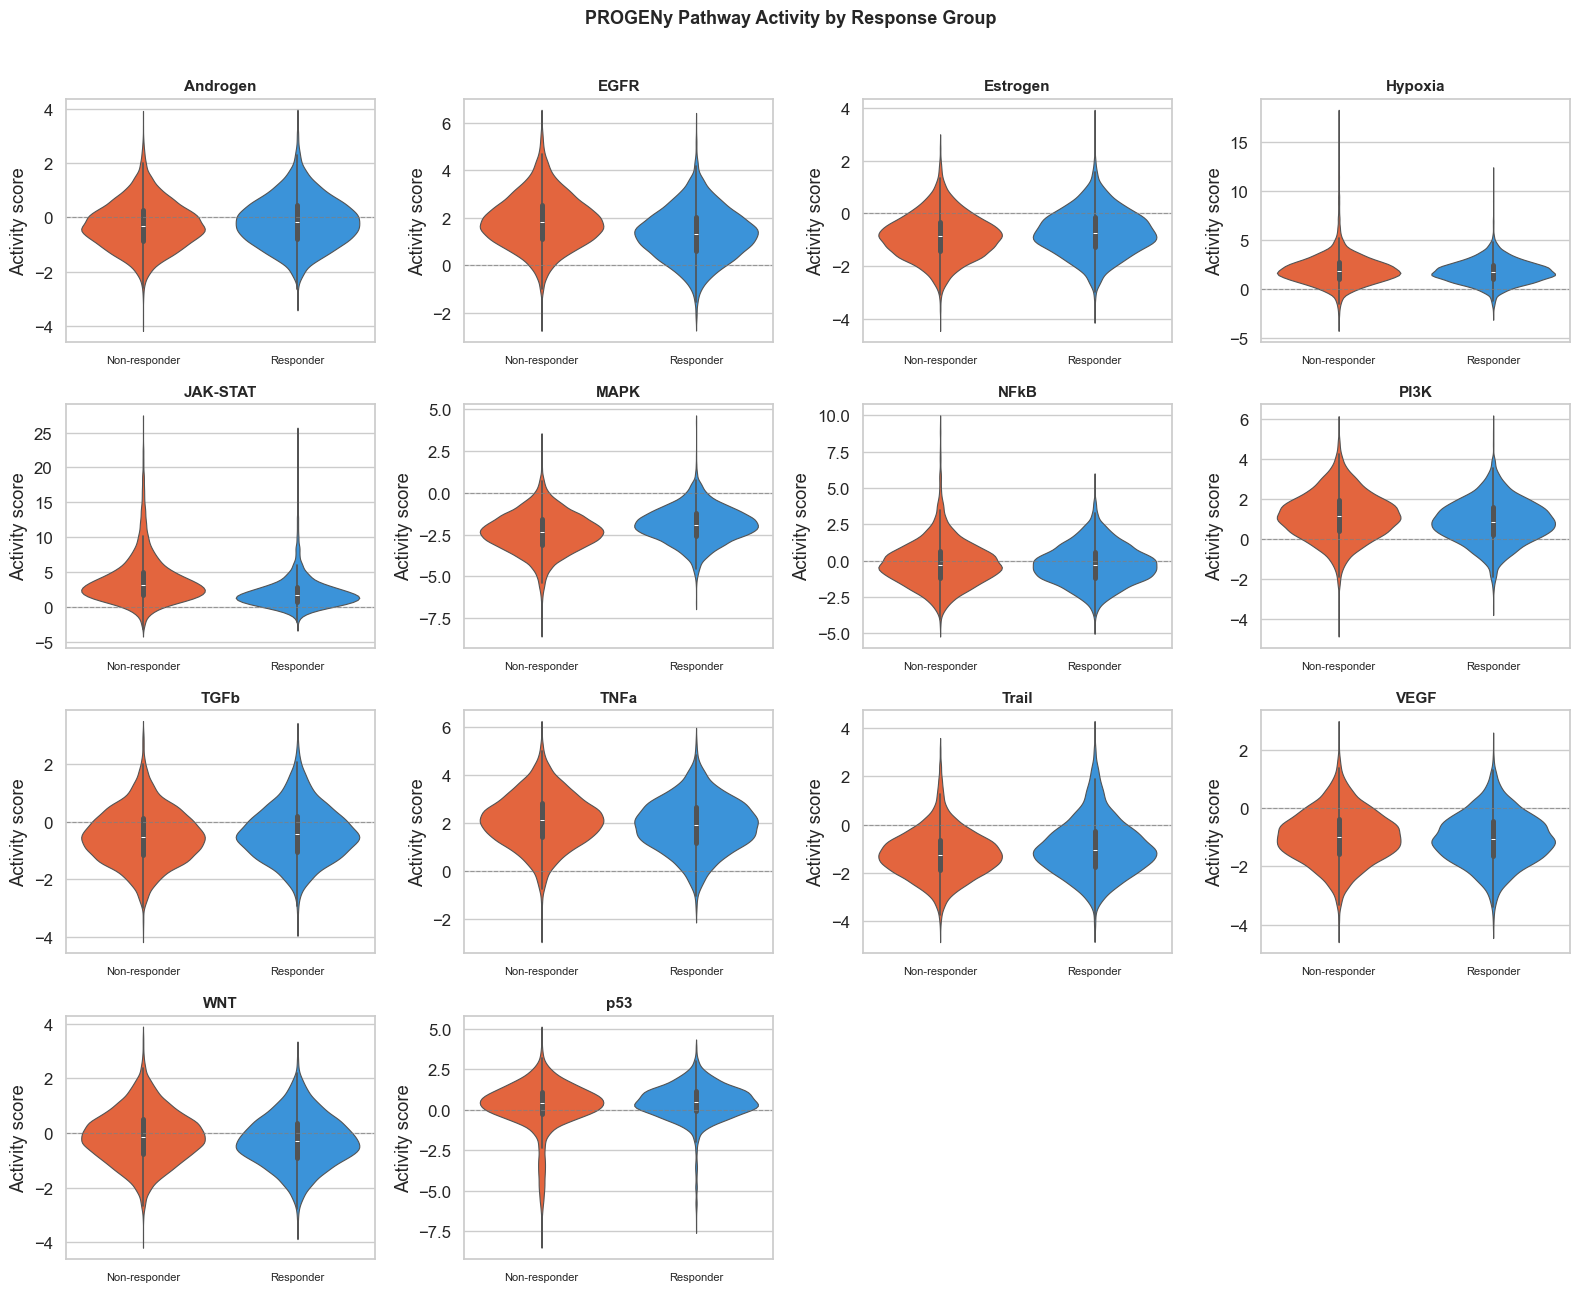

In [7]:
# Creating Violin plots for each PROGENy pathway activity for each response group.
pathway_cols = pathway_qc.columns.tolist()
pathway_qc["response_label"] = adata.obs["response_label"].values

# Plotting (subplot layouts, response colors, one violin plot per pathway, zero lining --> visual choice)
n_pathways = len(pathway_cols)
ncols = 4
nrows = (n_pathways + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.2))
axes = axes.flatten()
colors = {"Responder": "#2196F3","Non-responder": "#FF5722"}
for i, pathway in enumerate(pathway_cols):
    ax = axes[i]
    sns.violinplot( data=pathway_qc,x="response_label",y=pathway,palette=colors,ax=ax,inner="box",linewidth=0.8)
    ax.set_title(pathway, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Activity score")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.tick_params(axis="x", labelsize=8)


# Hiding empty subplot spaces 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle("PROGENy Pathway Activity by Response Group",fontsize=13,fontweight="bold",y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / "violin_pathway_response.png", bbox_inches="tight")
plt.show()


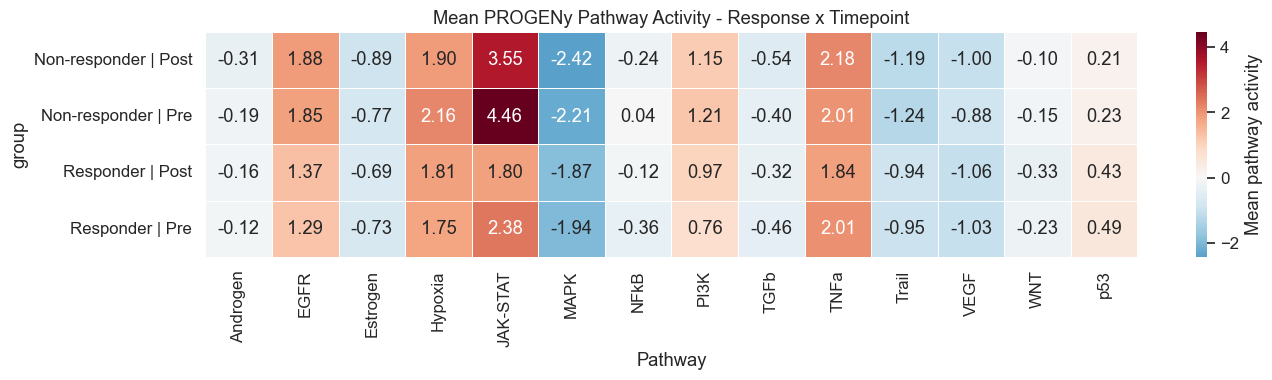

In [8]:
# Creating a heatmap of mean PROGENy pathway activity 
# for each response and timepoint combination.
pathway_qc["timepoint"] = adata.obs["timepoint"].values
pathway_qc["group"] = (pathway_qc["response_label"].astype(str) + " | "+ pathway_qc["timepoint"].astype(str))

# Calculating the mean pathway activity across all cells per response + timepoint group
mean_by_group = (pathway_qc.groupby("group", observed=True)[pathway_cols].mean())


# Plotting
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(mean_by_group,cmap="RdBu_r",center=0,annot=True,fmt=".2f",linewidths=0.4,ax=ax,cbar_kws={"label": "Mean pathway activity"})
ax.set_title("Mean PROGENy Pathway Activity - Response x Timepoint")
ax.set_xlabel("Pathway")
plt.tight_layout()
plt.savefig(figures_dir / "pathway_heatmap_response_timepoint.png", bbox_inches="tight")
plt.show()

Index([], dtype='object', name='cell_id')


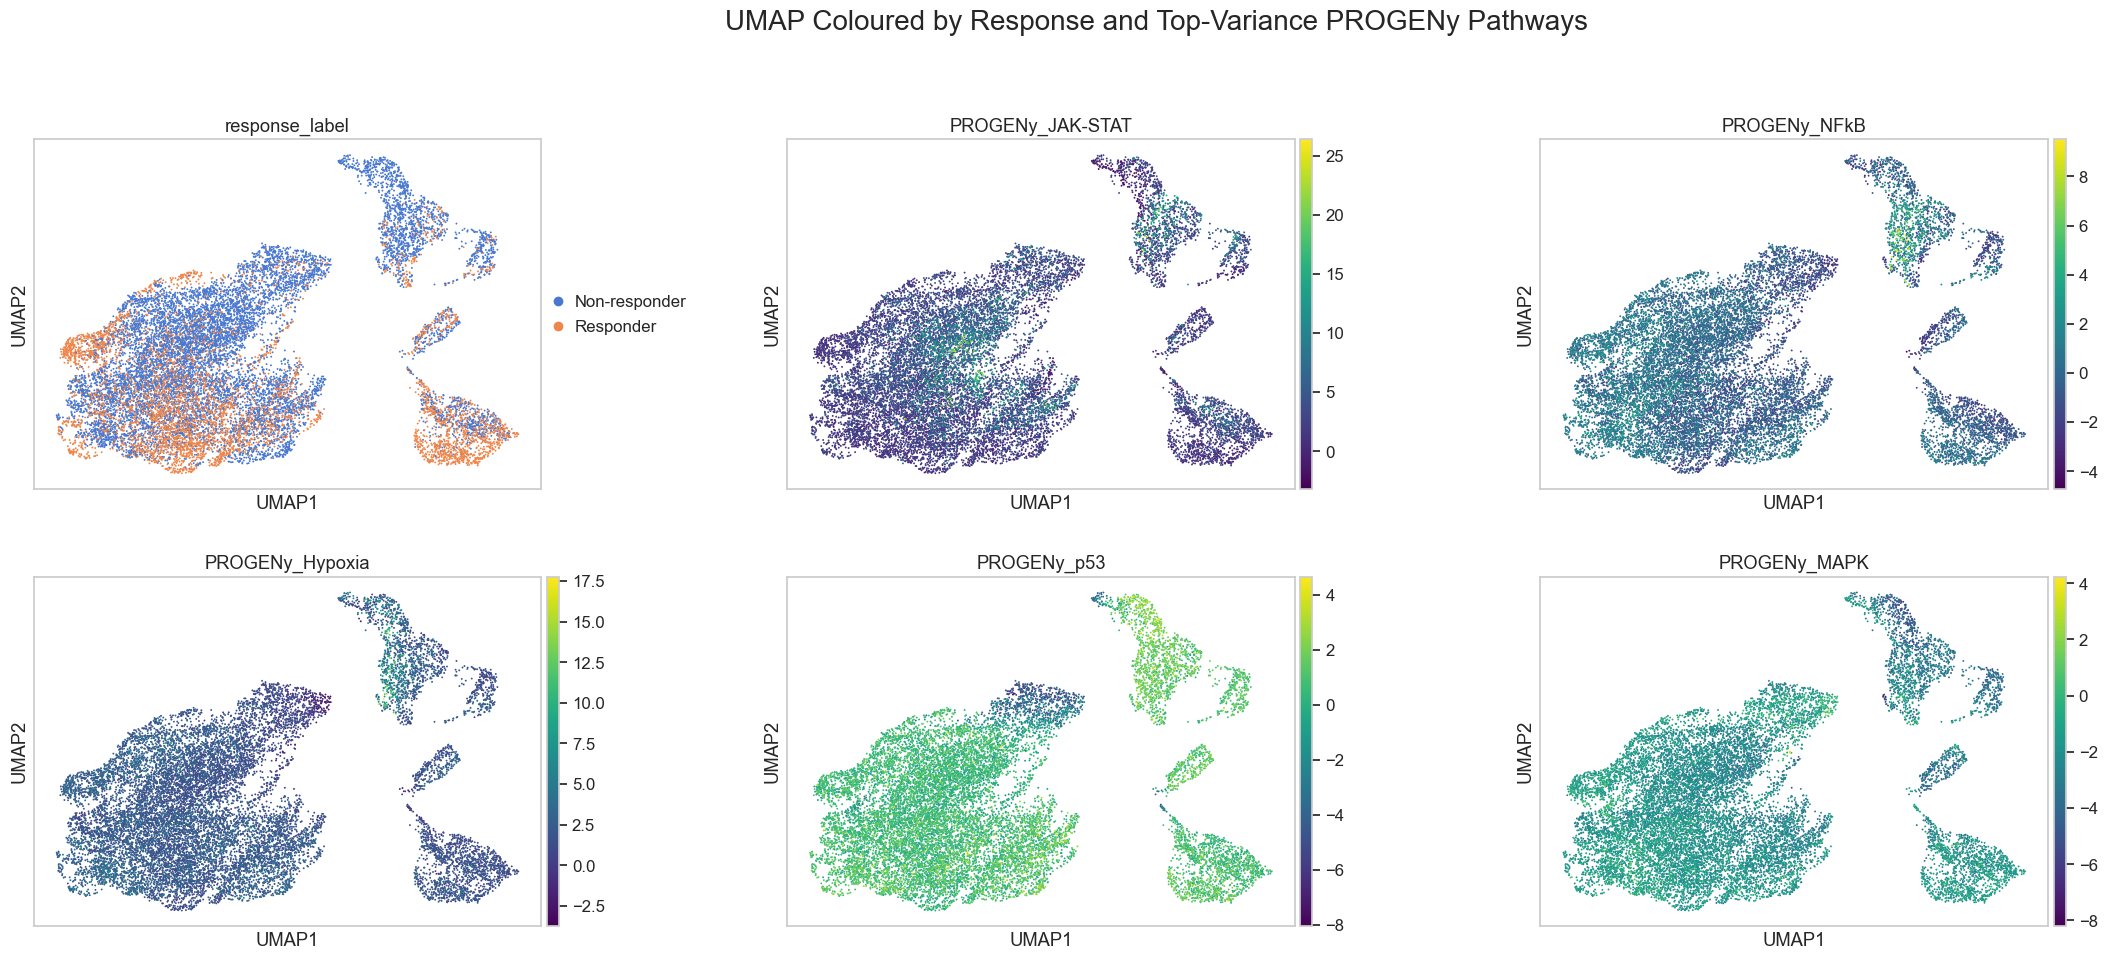

In [9]:
# Since in EDA we have different UMAPs for each feauture group
# Creation of UMAP coloured by top-variance pathways to:
# visualize whether the pathways with the highest cell-level variance
# follow the cellular structure already visible in the gene-expression UMAPs.

# Selecting top five pathways with the highest variance
top5_pathways = (variances.sort_values(ascending=False).head(5).index.tolist())

# Check that pathway_df and adata contain the same cells
missing_cells = adata.obs_names.difference(pathway_qc.index)
print (missing_cells)

# Adding pathway scores temporarily to adata.obs.
# Reindexing aligns the pathway scores with the exact cell order in adata.
# Creating the PCA and the UMAP for each pathway
temporary_columns = []

for pathway in top5_pathways:
    column_name = f"PROGENy_{pathway}"
    adata.obs[column_name] = (pathway_qc[pathway].reindex(adata.obs_names).astype(float))
    temporary_columns.append(column_name)
    sc.tl.pca(adata,n_comps=50,random_state=SEED)
    sc.pp.neighbors(adata,n_neighbors=15,n_pcs=20,random_state=SEED)
    sc.tl.umap(adata,random_state=SEED)

# Plotting response status and the top five pathway activity scores
color_keys = ["response_label"] + temporary_columns
sc.pl.umap(adata,color=color_keys,ncols=3,wspace=0.35,cmap="viridis",show=False)
plt.suptitle("UMAP Coloured by Response and Top-Variance PROGENy Pathways",fontsize=20,y=1.02)
plt.savefig(figures_dir / "umap_pathways.png",dpi=150,bbox_inches="tight")
plt.show()
plt.close()


# Removing only the temporary pathway columns used and added for this plot
adata.obs.drop(columns=temporary_columns,inplace=True,errors="ignore")

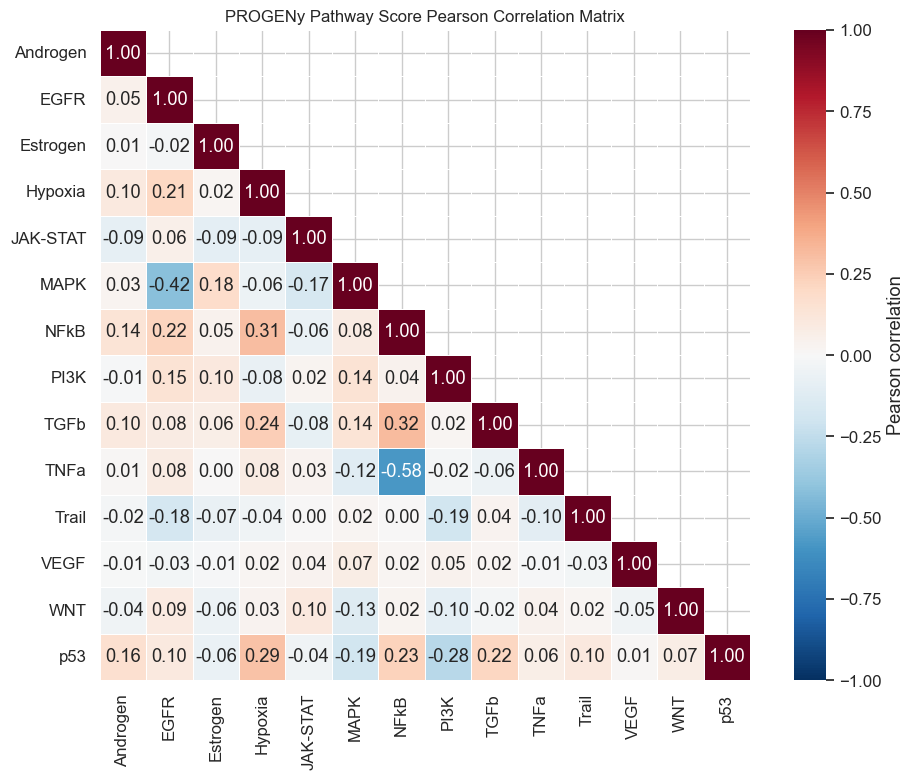

In [10]:
# Creating and Calculating pathway score pearson correlation matrix
# in order to examine whether some PROGENy pathway scores contain similar information across cells.
# Selecting only the pathway activity score columns.
pathway_corr_df = pathway_qc[pathway_cols].copy()

# Calculating pairwise Pearson correlations between pathway scores
corr = pathway_corr_df.corr(method="pearson")

# Masking the upper triangle to avoid displaying each correlation twice since the matrix is symmetrical. 
mask = np.triu(np.ones_like(corr, dtype=bool),k=1)

# Plotting 
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,mask=mask,cmap="RdBu_r",center=0,vmin=-1,vmax=1,annot=True,fmt=".2f",linewidths=0.4,square=True, \
    ax=ax,cbar_kws={"label": "Pearson correlation"})
ax.set_title("PROGENy Pathway Score Pearson Correlation Matrix",fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / "pathway_pearson_correlation_matrix.png",dpi=150,bbox_inches="tight")
plt.show()
plt.close()

## New AnnData creation Genes + Pathways

In [11]:
# Making a new naming (prefix addition PROGENy_) of the pathways in order to search for them and add them
# while also aligning pathway scores with the exact cell order in Anndata
pathway_df = pathway_qc.drop(columns=["response_label", "timepoint", "group"],errors="ignore").copy()
pathway_df.columns = [col if col.startswith("PROGENy_") else f"PROGENy_{col}"for col in pathway_df.columns]
pathway_df = pathway_df.reindex(adata.obs_names)

# Checking if missing values where introduced during alignment 
if pathway_df.isna().any().any():
    raise ValueError("Missing values found.")

# Creating a new anndata and adding the pathway activity scores
adata_pathways = adata.copy()
adata_pathways.obs = adata_pathways.obs.join(pathway_df)

print("New columns added:")
for col in adata_pathways.obs.columns:
    if col.startswith("PROGENy_"):
        print(col)

print(f"\nNew AnnData shape: {adata_pathways.shape}")
print("Number of pathway columns:",sum( col.startswith("PROGENy_")for col in adata_pathways.obs.columns))

New columns added:
PROGENy_Androgen
PROGENy_EGFR
PROGENy_Estrogen
PROGENy_Hypoxia
PROGENy_JAK-STAT
PROGENy_MAPK
PROGENy_NFkB
PROGENy_PI3K
PROGENy_TGFb
PROGENy_TNFa
PROGENy_Trail
PROGENy_VEGF
PROGENy_WNT
PROGENy_p53

New AnnData shape: (16291, 10019)
Number of pathway columns: 14


In [ ]:
# Saving new Anndata
pathway_anndata = output_dir /"filtered_anndata_pathways.h5ad"
adata_pathways.write_h5ad(pathway_anndata)
print(f"\nSaved extended AnnData: {pathway_anndata}")

# Reloading
print("----------------------------------------------------")
adata = sc.read_h5ad(pathway_anndata)
# Reloading the anndata for re-checking its values and shape.
print(f"AnnData shape: {adata.shape}")
print(f"obs columns: {list(adata.obs.columns)}")


Saved extended AnnData: ..\outputs\filtered_anndata_pathways.h5ad
----------------------------------------------------
AnnData shape: (16291, 10019)
obs columns: ['sample', 'patient_timepoint', 'response_label', 'therapy', 'timepoint', 'patient_id', 'response', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'PROGENy_Androgen', 'PROGENy_EGFR', 'PROGENy_Estrogen', 'PROGENy_Hypoxia', 'PROGENy_JAK-STAT', 'PROGENy_MAPK', 'PROGENy_NFkB', 'PROGENy_PI3K', 'PROGENy_TGFb', 'PROGENy_TNFa', 'PROGENy_Trail', 'PROGENy_VEGF', 'PROGENy_WNT', 'PROGENy_p53']


---

# References
 
> [9].Package ‘decoupleR’: https://www.bioconductor.org/packages//release/bioc/manuals/decoupleR/man/decoupleR.pdf </br>
> [10].decoupler.mt.mlm: https://decoupler.readthedocs.io/en/latest/api/generated/decoupler.mt.mlm.html </br>
> [11]. decoupler.pp.get_obsm: https://decoupler.readthedocs.io/en/latest/api/generated/decoupler.pp.get_obsm.html </br>
 